In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [2]:
#load data
cancer = load_breast_cancer()

# Exercícios

## 1.

Aplique o algoritmo de regressão logística ao conj de dados "breast_cancer", utilizando os
valores de C={0.01, 1, 100}. Calcule a exatidão sobre o conj. de treino e de teste.

In [3]:
#split data
X_train, X_test, y_train, y_test = train_test_split(
	cancer.data, cancer.target, stratify=cancer.target, random_state=66)

In [4]:
#regressão logística com regularização L2 para C={0.01, 1, 100}
C_vals = [0.01, 1, 100]
models_L2 = []
exatidao_treino = []
exatidao_teste = []

for c in C_vals:
    #build model
    logreg = LogisticRegression(C=c, penalty="l2", solver="liblinear", max_iter=5000)
    #train model
    logreg.fit(X_train, y_train)
    #save model
    models_L2.append(logreg)
    #metrics
    exatidao_treino.append(logreg.score(X_train, y_train))
    exatidao_teste.append(logreg.score(X_test, y_test))
    
#tabela com resultados
df = pd.DataFrame({
    "C": list(C_vals),
    "exatidao_treino": exatidao_treino,
    "exatidao_teste": exatidao_teste
})

print(df.to_string(index=False))

     C  exatidao_treino  exatidao_teste
  0.01         0.938967        0.923077
  1.00         0.971831        0.937063
100.00         0.981221        0.944056


## 2.

Faça um gráfico com a magnitude dos coeficientes dos 3 modelos construídos.

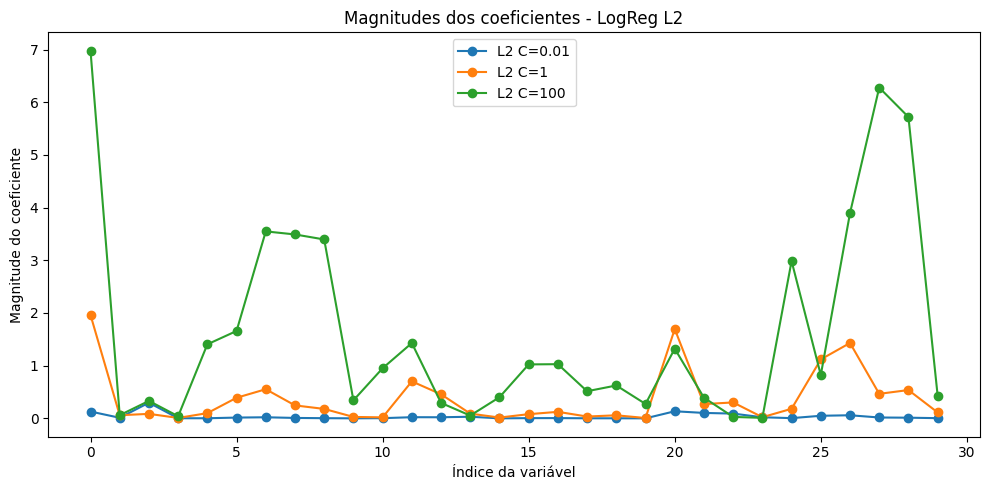

In [5]:
#gráfico da magnitude dos coeficientes
plt.figure(figsize=(10, 5))
for c, model in zip(C_vals, models_L2):
    plt.plot(np.abs(model.coef_.ravel()), marker="o", label=f"L2 C={c}")
    
plt.xlabel("Índice da variável")
plt.ylabel("Magnitude do coeficiente")
plt.title("Magnitudes dos coeficientes - LogReg L2")
plt.legend()
plt.tight_layout()
plt.show()

## 3.

Construa modelos com os mesmos valores de C, mas utilizando a regularização L1. Faça o gráfico
com a magnitude dos coeficientes dos 3 modelos.

     C  exatidao_treino  exatidao_teste
  0.01         0.920188        0.909091
  1.00         0.974178        0.944056
100.00         0.995305        0.972028


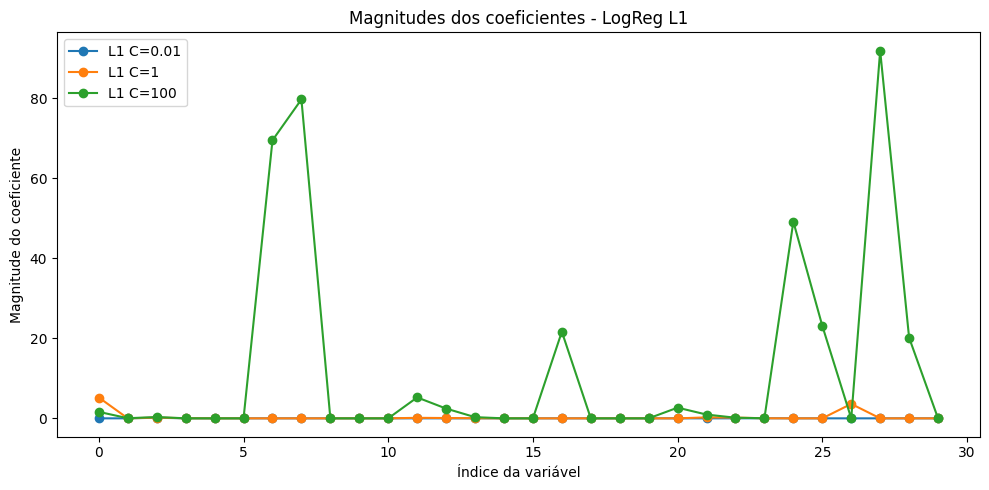

In [6]:
#regressão logística com regularização L1 para C={0.01, 1, 100}
C_vals = [0.01, 1, 100]
models_L1 = []
exatidao_treino = []
exatidao_teste = []

for c in C_vals:
    #build model
    logreg = LogisticRegression(C=c, penalty="l1", solver="liblinear", max_iter=5000)
    #train model
    logreg.fit(X_train, y_train)
    #save model
    models_L1.append(logreg)
    #metrics
    exatidao_treino.append(logreg.score(X_train, y_train))
    exatidao_teste.append(logreg.score(X_test, y_test))
    
#tabela com resultados
df = pd.DataFrame({
    "C": list(C_vals),
    "exatidao_treino": exatidao_treino,
    "exatidao_teste": exatidao_teste
})

print(df.to_string(index=False))

#gráfico da magnitude dos coeficientes
plt.figure(figsize=(10, 5))
for c, model in zip(C_vals, models_L1):
    plt.plot(np.abs(model.coef_.ravel()), marker="o", label=f"L1 C={c}")
    
plt.xlabel("Índice da variável")
plt.ylabel("Magnitude do coeficiente")
plt.title("Magnitudes dos coeficientes - LogReg L1")
plt.legend()
plt.tight_layout()
plt.show()